# Machine Learning Pipeline to Analyze and Predict EV Range Anxiety

## Introduction

This notebook presents a machine learning pipeline to analyze and predict EV adoption using user demographics, daily commute distance, and range anxiety level. The objective is to identify key predictive features, evaluate behavioral patterns, and understand how range anxiety and commute needs influence the likelihood of EV adoption. Insights from this analysis can inform manufacturing and infrastructure strategies.

**Research Question:**  
How do range anxiety level and daily commute distance influence the likelihood of EV adoption?

- **Coverage:** Distribution of EV users across demographic groups, commute distances, and range anxiety levels.
- **Density:** Concentration of range anxiety occurrences normalized across driving distances or geographic regions.
- **Accessibility:** Ratios comparing perceived range anxiety to daily user travel requirements and charging access.
- **Composition Mix:** Breakdown of user demographic profiles and charging options.
- **Metric Alignment:** Correlation between range anxiety, commute distance, charging availability, and reported adoption rates.


---

## Python Libraries

This machine learning workflow uses standard Python data science and modeling libraries:
- `pandas` - for data loading, manipulation, and tabular dataset handling
- `numpy` - for vector operations and numerical calculations
- `scipy` - for reading and parsing dataset files in ARFF format
- `scikit-learn` - for missing value imputation, feature encoding and scaling, dimensionality reduction (PCA), machine learning pipelines, model training (Logistic Regression, Random Forests), hyperparameter tuning, and evaluation metrics

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from scipy.stats import zscore


from src import data_utils, feature_handling

%matplotlib inline

## Data Loading & Initial Inspection

1. **Dataset Ingestion**:
   - Load raw dataset into a Pandas DataFrame to establish the core data structure.

2. **Preliminary Inspection**:
   - Check DataFrame dimensions (`shape`), column names, and infer data types (`info()`).
   - Preview initial records (`head()`) to verify schema integrity and proper parsing before starting ETL.

In [2]:
# Load data
df = pd.read_csv('data/ev_adoption.csv')
df.head()
print(f"Number of rows: {df.shape[0]}")
print(df.dtypes)
print(f"Unique entities: {df[df.columns[0]].nunique()}")

Number of rows: 10000
Buyer_ID                           str
Age                              int64
Gender                             str
Annual_Income_USD              float64
City_Type                          str
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Current_Car_Type                   str
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Home_Charging_Possible             str
Environmental_Concern_Level    float64
Subsidy_Available                  str
Range_Anxiety_Level                str
Will_Buy_EV                        str
dtype: object
Unique entities: 10000


## Exploratory Data Analysis (EDA) & Data Processing

1. **Schema Standardization & Deduplication**:
   - Convert column names to lowercase and strip whitespace for naming consistency.
   - Remove duplicate rows to ensure data integrity.

2. **Missing Value Treatment**:
   - Inspect missing value counts across all features.
   - Clean missing data using context-appropriate imputation (mean for numerical, mode for categorical).

3. **Outlier Filtering**:
   - Target key numerical columns (`age`, `annual_income_usd`, `daily_commute_km`, `environmental_concern_level`).
   - Calculate Z-scores and remove rows exceeding the $Z = 2.5$ threshold to reduce variance and distribution skew.

4. **Validation & Visual Inspection**:
   - Generate summary statistics (`describe()`) and compute post-filtering maximum Z-scores to verify outlier suppression.
   - Plot feature distribution histograms to assess data normality and spread prior to downstream modeling.

--- Step 1: Standardizing columns & removing duplicates ---

--- Step 2: Inspecting missing values ---
Missing values per column:
buyer_id                       0
age                            0
gender                         0
annual_income_usd              0
city_type                      0
daily_commute_km               0
number_of_cars_owned           0
current_car_type               0
charging_stations_near_home    0
charging_stations_near_work    0
home_charging_possible         0
environmental_concern_level    0
subsidy_available              0
range_anxiety_level            0
will_buy_ev                    0
dtype: int64


--- Step 3: Removing outliers (Z-score threshold = 2.5) ---
Row count: 1237 -> 1237 (Removed 0)

--- Step 4: Inspection & verification ---
DataFrame summary statistics:
               age  annual_income_usd  daily_commute_km  number_of_cars_owned  \
count  1237.000000        1237.000000       1237.000000           1237.000000   
mean     46.963622       8264

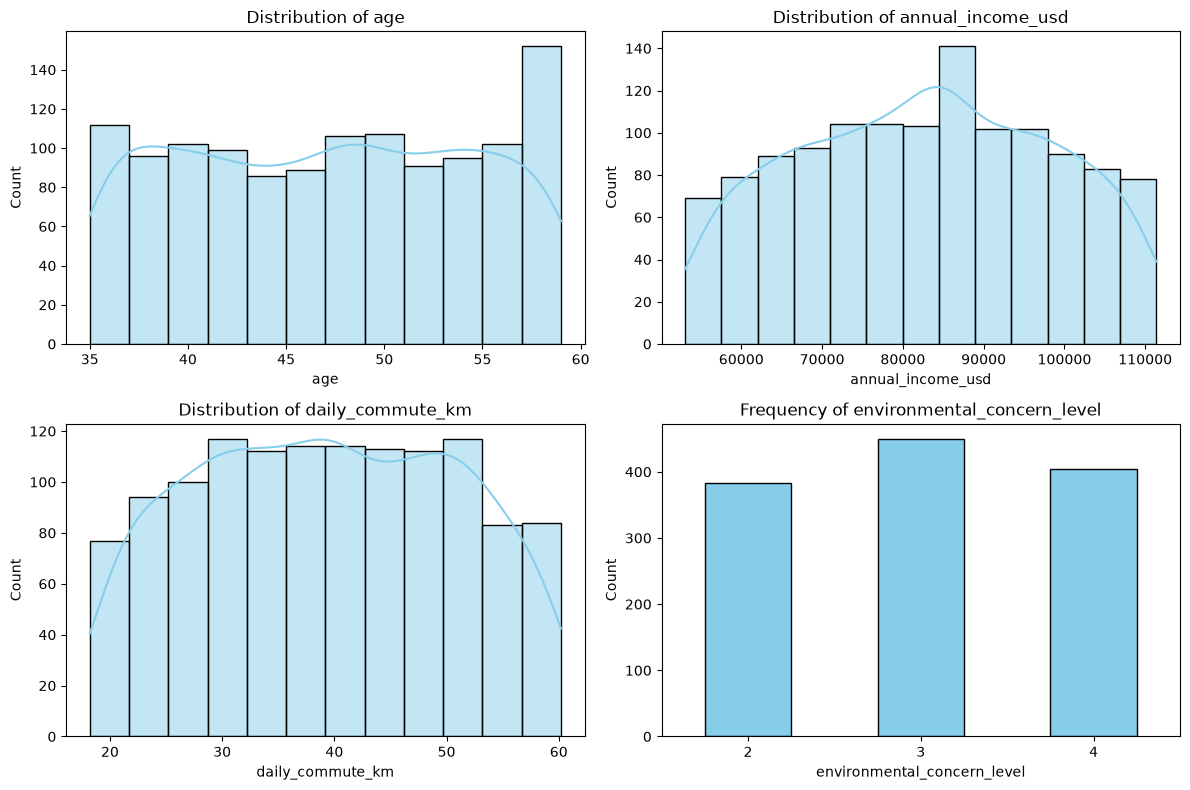

In [21]:
# ==========================================
# 1. SCHEMA STANDARDIZATION & DEDUPLICATION
# ==========================================
print("--- Step 1: Standardizing columns & removing duplicates ---")
df.columns = df.columns.str.strip().str.lower()
df = df.drop_duplicates()

# ==========================================
# 2. MISSING VALUE INSPECTION (NO IMPUTATION)
# ==========================================
print("\n--- Step 2: Inspecting missing values ---")
print(f"Missing values per column:\n{df.isna().sum()}\n")

# ==========================================
# 3. OUTLIER FILTERING (OPTIONAL)
# ==========================================
print("\n--- Step 3: Removing outliers (Z-score threshold = 2.5) ---")
plot_cols = [
    "age",
    "annual_income_usd",
    "daily_commute_km",
    "environmental_concern_level",
]

initial_rows = len(df)
df = data_utils.remove_outliers_by_zscore(df, plot_cols)
final_rows = len(df)

print(
    f"Row count: {initial_rows} -> {final_rows} (Removed"
    f" {initial_rows - final_rows})"
)

# ==========================================
# 4. VALIDATION & VISUALIZATION
# ==========================================
print("\n--- Step 4: Inspection & verification ---")
print("DataFrame summary statistics:")
print(df.describe())

z_scores = (df[plot_cols] - df[plot_cols].mean()).abs() / df[plot_cols].std(ddof=0)
print("\nMax Z-scores after filtering:")
print(z_scores.max())

print("\nPlotting feature distributions")
data_utils.plot_distributions(df, cols=plot_cols)


## Feature Selection

1. **Target Definition**:
   - Set `will_buy_ev` as the target variable to evaluate EV adoption behavior.

2. **Predictor Subset Selection**:
   - **Demographics & Economics**: Retain `age`, `annual_income_usd`, and `city_type`.
   - **Behavioral & Psychological Drivers**: Focus on `daily_commute_km` and `range_anxiety_level` to detect adoption tipping points.
   - **Infrastructure & Financial Incentives**: Include `charging_stations_near_home`, `charging_stations_near_work`, `home_charging_possible`, and `subsidy_available`.

3. **Dimensionality & Noise Reduction**:
   - Drop non-essential attributes to minimize feature noise and focus model evaluation on high-impact variables.

In [20]:
# 1. Include target variable alongside selected predictors
selected_columns = [
    'age',
    'annual_income_usd',
    'city_type',
    'daily_commute_km',
    'charging_stations_near_home',
    'charging_stations_near_work',
    'home_charging_possible',
    'subsidy_available',
    'range_anxiety_level',
    'will_buy_ev'  # Target variable
]

# 2. Subset the DataFrame explicitly
df_selected = df[selected_columns].copy()

# 3. Inspect data types and structure
print(df_selected.info())

# 4. Check cardinality to identify zero-variance or unencoded columns
print(df_selected.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1237 non-null   int64  
 1   annual_income_usd            1237 non-null   float64
 2   city_type                    1237 non-null   str    
 3   daily_commute_km             1237 non-null   float64
 4   charging_stations_near_home  1237 non-null   int64  
 5   charging_stations_near_work  1237 non-null   int64  
 6   home_charging_possible       1237 non-null   str    
 7   subsidy_available            1237 non-null   str    
 8   range_anxiety_level          1237 non-null   str    
 9   will_buy_ev                  1237 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 96.8 KB
None
age                              25
annual_income_usd              1185
city_type                         3
daily_commute_km                397


## Machine Learning Pipeline



In [ ]:
# 1. Data Cleaning
# - Standardize column names
# - Remove duplicates

# 2. Feature Selection
# - Select relevant features and target variable (X and y)

# 3. Train/Test Split
# - x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=..., random_state=...)

# 4. Preprocessing & Feature Engineering Pipeline
# - Use ColumnTransformer to:
#     - Impute missing values (SimpleImputer)
#     - Encode categorical features (OneHotEncoder, OrdinalEncoder)
#     - Scale numeric features (StandardScaler)
#     - Add any custom feature engineering steps

# 5. Model Selection
# - Choose and add the estimator (e.g., LogisticRegression, RandomForestClassifier) to the pipeline

# 6. Training
# - Fit the pipeline on x_train, y_train

# 7. Prediction & Evaluation
# - Predict on x_test
# - Evaluate and print results (accuracy, confusion matrix, etc.)


## Data Analysis
# go over results 

# draw conclusions
